# Chi-Square Tests

Topic 05 of the Statistical Inference & Hypothesis Testing repo. Topics 01-04 all dealt with continuous measurements (means, variances). Chi-square tests instead work on **counts** of categorical outcomes — does an observed distribution of categories match an expected one (goodness-of-fit), or are two categorical variables associated (independence)? Both are built from scratch here, validated against `scipy.stats`, and the notebook then does what a typical intro treatment skips: directly demonstrates the chi-square approximation breaking down at small expected cell counts, and shows Fisher's Exact Test as the fix.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. Chi-Square Goodness-of-Fit Test, Built From Scratch

Tests whether observed category counts match an expected distribution:

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}, \qquad df = k - 1$$

In [2]:
def chi_square_gof_scratch(observed, expected):
    chi2_stat = np.sum((observed - expected) ** 2 / expected)
    df = len(observed) - 1
    p_value = 1 - stats.chi2.cdf(chi2_stat, df=df)
    return chi2_stat, df, p_value

print("Goodness-of-fit function defined.")

Goodness-of-fit function defined.


In [3]:
# A fair six-sided die rolled 300 times -- expected 50 per face if truly fair
rng = np.random.default_rng(1)
n_rolls = 300
true_die_probs = np.array([1/6] * 6)  # a genuinely fair die
observed_rolls = rng.multinomial(n_rolls, true_die_probs)
expected_rolls = np.array([n_rolls / 6] * 6)

chi2_manual, df_manual, p_manual = chi_square_gof_scratch(observed_rolls, expected_rolls)
chi2_scipy, p_scipy = stats.chisquare(observed_rolls, expected_rolls)

print(f"Observed counts: {observed_rolls}")
print(f"Expected counts: {expected_rolls}")
print(f"Manual chi2: {chi2_manual:.6f}  |  scipy chi2: {chi2_scipy:.6f}")
print(f"Manual p:    {p_manual:.6f}  |  scipy p:    {p_scipy:.6f}")
assert abs(chi2_manual - chi2_scipy) < 1e-9
assert abs(p_manual - p_scipy) < 1e-9
print("Manual goodness-of-fit test matches scipy.stats.chisquare exactly.")

Observed counts: [43 54 59 43 54 47]
Expected counts: [50. 50. 50. 50. 50. 50.]
Manual chi2: 4.400000  |  scipy chi2: 4.400000
Manual p:    0.493374  |  scipy p:    0.493374
Manual goodness-of-fit test matches scipy.stats.chisquare exactly.


In [4]:
print(f"H0: the die is fair (each face has probability 1/6)")
print(f"p-value: {p_manual:.4f}  vs  alpha=0.05")
print(f"Decision: {'REJECT H0 -- evidence the die is unfair' if p_manual < 0.05 else 'FAIL TO REJECT H0 -- consistent with a fair die'}")
print(f"(This die WAS actually fair by construction, so this decision is the correct one to expect most of the time.)")

H0: the die is fair (each face has probability 1/6)
p-value: 0.4934  vs  alpha=0.05
Decision: FAIL TO REJECT H0 -- consistent with a fair die
(This die WAS actually fair by construction, so this decision is the correct one to expect most of the time.)


## 2. Type I Error Calibration, and Detecting a Real Bias

As with the t-test in Topic 04, the chi-square test's alpha promise should hold under a true null. This section verifies that directly, then shows the test correctly detecting a genuinely loaded die.

In [5]:
def simulate_gof_type1_error(true_probs, n_rolls, n_repeats, alpha, rng):
    k = len(true_probs)
    expected = np.array([n_rolls / k] * k)
    false_positives = 0
    for _ in range(n_repeats):
        observed = rng.multinomial(n_rolls, true_probs)
        _, p = stats.chisquare(observed, expected)
        if p < alpha:
            false_positives += 1
    return false_positives / n_repeats

print("GOF Type I error simulator defined.")

GOF Type I error simulator defined.


In [6]:
rng_t1 = np.random.default_rng(2)
empirical_rate = simulate_gof_type1_error(true_die_probs, 300, 8000, 0.05, rng_t1)
print(f"Nominal alpha: 0.05")
print(f"Empirical Type I error rate (fair die, H0 true, 8000 simulations): {empirical_rate:.4f}")
assert abs(empirical_rate - 0.05) < 0.015
print("Confirmed: matches nominal alpha to within Monte Carlo noise.")

Nominal alpha: 0.05
Empirical Type I error rate (fair die, H0 true, 8000 simulations): 0.0531
Confirmed: matches nominal alpha to within Monte Carlo noise.


In [7]:
# Now a GENUINELY loaded die -- face 6 comes up twice as often as it should
loaded_die_probs = np.array([0.15, 0.15, 0.15, 0.15, 0.15, 0.25])
loaded_observed = rng.multinomial(n_rolls, loaded_die_probs)

chi2_loaded, df_loaded, p_loaded = chi_square_gof_scratch(loaded_observed, expected_rolls)
print(f"Observed counts from a LOADED die (face 6 has true probability 0.25, not 1/6): {loaded_observed}")
print(f"chi2 = {chi2_loaded:.4f}, p = {p_loaded:.6f}")
print(f"Decision: {'REJECT H0 -- correctly detects the loaded die' if p_loaded < 0.05 else 'FAIL TO REJECT H0 -- missed the bias this time'}")

Observed counts from a LOADED die (face 6 has true probability 0.25, not 1/6): [45 47 43 47 49 69]
chi2 = 9.0800, p = 0.105915
Decision: FAIL TO REJECT H0 -- missed the bias this time


## 3. Chi-Square Test of Independence, Built From Scratch

Tests whether two categorical variables are associated, using a contingency table:

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}, \qquad E_{ij} = \frac{(\text{row}_i \text{ total}) \times (\text{col}_j \text{ total})}{\text{grand total}}, \qquad df = (r-1)(c-1)$$

In [8]:
def chi_square_independence_scratch(contingency_table):
    table = np.asarray(contingency_table, dtype=float)
    row_totals = table.sum(axis=1, keepdims=True)
    col_totals = table.sum(axis=0, keepdims=True)
    grand_total = table.sum()
    expected = row_totals @ col_totals / grand_total

    chi2_stat = np.sum((table - expected) ** 2 / expected)
    df = (table.shape[0] - 1) * (table.shape[1] - 1)
    p_value = 1 - stats.chi2.cdf(chi2_stat, df=df)
    return chi2_stat, df, p_value, expected

print("Test-of-independence function defined.")

Test-of-independence function defined.


In [9]:
# Smoking status x Exercise habit -- a constructed contingency table with a real, moderate association
contingency = np.array([
    [30, 10],   # Smoker:     [Exercises regularly, Does not]
    [20, 40],   # Non-smoker: [Exercises regularly, Does not]
])

chi2_manual_ind, df_manual_ind, p_manual_ind, expected_ind = chi_square_independence_scratch(contingency)
chi2_scipy_ind, p_scipy_ind, df_scipy_ind, expected_scipy_ind = stats.chi2_contingency(contingency, correction=False)

print(f"Contingency table:\n{contingency}")
print(f"Manual chi2: {chi2_manual_ind:.6f}  |  scipy chi2: {chi2_scipy_ind:.6f}")
print(f"Manual p:    {p_manual_ind:.6f}  |  scipy p:    {p_scipy_ind:.6f}")
assert abs(chi2_manual_ind - chi2_scipy_ind) < 1e-9
assert abs(p_manual_ind - p_scipy_ind) < 1e-9
print("Manual test of independence matches scipy.stats.chi2_contingency (correction=False) exactly.")

Contingency table:
[[30 10]
 [20 40]]
Manual chi2: 16.666667  |  scipy chi2: 16.666667
Manual p:    0.000045  |  scipy p:    0.000045
Manual test of independence matches scipy.stats.chi2_contingency (correction=False) exactly.


In [10]:
print(f"Expected counts under independence:\n{np.round(expected_ind, 2)}")
print(f"\nH0: smoking status and exercise habit are independent")
print(f"p-value: {p_manual_ind:.6f}  vs  alpha=0.05")
print(f"Decision: {'REJECT H0 -- evidence of a real association' if p_manual_ind < 0.05 else 'FAIL TO REJECT H0'}")

Expected counts under independence:
[[20. 20.]
 [30. 30.]]

H0: smoking status and exercise habit are independent
p-value: 0.000045  vs  alpha=0.05
Decision: REJECT H0 -- evidence of a real association


## 4. Yates' Continuity Correction for 2x2 Tables

$$\chi^2_{\text{Yates}} = \sum_{i,j} \frac{(|O_{ij}-E_{ij}|-0.5)^2}{E_{ij}}$$

For 2x2 tables specifically, the discrete counts are being approximated by a continuous chi-square distribution; Yates' correction shrinks the statistic slightly to compensate. `scipy` applies it by default for 2x2 tables. This section measures how much it actually changes the result.

In [11]:
chi2_yates, p_yates, df_yates, expected_yates = stats.chi2_contingency(contingency, correction=True)
print(f"Without Yates' correction: chi2={chi2_manual_ind:.4f}, p={p_manual_ind:.6f}")
print(f"With Yates' correction:    chi2={chi2_yates:.4f}, p={p_yates:.6f}")
print(f"Difference in chi2: {abs(chi2_manual_ind - chi2_yates):.4f}")
print(f"\nYates' correction always makes the statistic smaller (more conservative) -- "
      f"{'here it changed the decision at alpha=0.05' if (p_manual_ind < 0.05) != (p_yates < 0.05) else 'here it did not change the decision at alpha=0.05'}.")

Without Yates' correction: chi2=16.6667, p=0.000045
With Yates' correction:    chi2=15.0417, p=0.000105
Difference in chi2: 1.6250

Yates' correction always makes the statistic smaller (more conservative) -- here it did not change the decision at alpha=0.05.


In [12]:
# Show the correction's effect shrinks as the table's total sample size grows
scale_factors = [1, 5, 20]
correction_effect_rows = []
for scale in scale_factors:
    scaled_table = contingency * scale
    chi2_no_corr, p_no_corr, _, _ = stats.chi2_contingency(scaled_table, correction=False)
    chi2_with_corr, p_with_corr, _, _ = stats.chi2_contingency(scaled_table, correction=True)
    correction_effect_rows.append({
        "scale": scale, "total_n": int(scaled_table.sum()),
        "chi2_no_correction": round(chi2_no_corr, 3), "chi2_with_correction": round(chi2_with_corr, 3),
        "pct_change": round(100 * (chi2_no_corr - chi2_with_corr) / chi2_no_corr, 2),
    })
correction_df = pd.DataFrame(correction_effect_rows)
print(correction_df.to_string(index=False))
print("\nThe correction's relative effect shrinks as sample size grows -- it matters most for small tables.")

 scale  total_n  chi2_no_correction  chi2_with_correction  pct_change
     1      100              16.667                15.042        9.75
     5      500              83.333                81.675        1.99
    20     2000             333.333               331.669        0.50

The correction's relative effect shrinks as sample size grows -- it matters most for small tables.


## 5. Effect Size for Chi-Square: Cramer's V

Like Cohen's d in Topic 04, a chi-square p-value alone doesn't say how *strong* an association is.

$$V = \sqrt{\frac{\chi^2/n}{\min(r-1, c-1)}}$$

ranges from 0 (no association) to 1 (perfect association), and is comparable across tables of different sizes and sample sizes.

In [13]:
def cramers_v(contingency_table, chi2_stat):
    table = np.asarray(contingency_table)
    n = table.sum()
    r, c = table.shape
    return np.sqrt((chi2_stat / n) / min(r - 1, c - 1))

print("Cramer's V function defined.")

Cramer's V function defined.


In [14]:
v_smoking = cramers_v(contingency, chi2_manual_ind)
print(f"Cramer's V for the smoking/exercise table: {v_smoking:.4f}")
print("(conventionally, for a 2x2 table: <0.1 negligible, 0.1-0.3 small, 0.3-0.5 medium, >0.5 large)")

Cramer's V for the smoking/exercise table: 0.4082
(conventionally, for a 2x2 table: <0.1 negligible, 0.1-0.3 small, 0.3-0.5 medium, >0.5 large)


In [15]:
# Demonstrate V staying stable while raw chi2 grows with sample size alone (same proportions, bigger n)
rng_v = np.random.default_rng(3)
v_by_scale = []
for scale in [1, 5, 20, 100]:
    scaled_table = contingency * scale
    chi2_scaled, _, _, _ = stats.chi2_contingency(scaled_table, correction=False)
    v_scaled = cramers_v(scaled_table, chi2_scaled)
    v_by_scale.append({"scale": scale, "total_n": int(scaled_table.sum()), "chi2": round(chi2_scaled, 2), "cramers_V": round(v_scaled, 4)})

v_scale_df = pd.DataFrame(v_by_scale)
print(v_scale_df.to_string(index=False))
print(f"\nchi2 grows roughly linearly with n (same underlying proportions), but Cramer's V stays "
      f"essentially constant at ~{v_scale_df['cramers_V'].mean():.3f} -- V measures association STRENGTH, "
      f"independent of sample size, exactly like Cohen's d did for the t-test in Topic 04.")

 scale  total_n    chi2  cramers_V
     1      100   16.67     0.4082
     5      500   83.33     0.4082
    20     2000  333.33     0.4082
   100    10000 1666.67     0.4082

chi2 grows roughly linearly with n (same underlying proportions), but Cramer's V stays essentially constant at ~0.408 -- V measures association STRENGTH, independent of sample size, exactly like Cohen's d did for the t-test in Topic 04.


## 6. Where Chi-Square Breaks Down: Small Expected Counts

The chi-square distribution is only an *approximation* to the true (discrete) sampling distribution of the test statistic — a good one when expected cell counts are large, a poor one when they're small (the common rule of thumb: all expected counts should be $\ge 5$). This section demonstrates the approximation's real accuracy breaking down at small counts, by comparing the chi-square-based p-value to the TRUE p-value from an exact permutation-based simulation.

In [16]:
def true_pvalue_by_simulation(contingency_table, n_simulations, rng):
    table = np.asarray(contingency_table)
    row_totals = table.sum(axis=1)
    col_totals = table.sum(axis=0)
    n_total = table.sum()
    observed_chi2, _, _, _ = stats.chi2_contingency(table, correction=False)

    # Simulate the null (independence) by randomly reallocating cell counts consistent with the margins,
    # using a multivariate hypergeometric draw for the first row given fixed margins.
    extreme_count = 0
    for _ in range(n_simulations):
        row0_sim = rng.multivariate_hypergeometric(col_totals.astype(int), int(row_totals[0]))
        row1_sim = col_totals - row0_sim
        sim_table = np.array([row0_sim, row1_sim])
        sim_chi2, _, _, _ = stats.chi2_contingency(sim_table, correction=False) if sim_table.min() > 0 else (0, 1, 0, 0)
        if sim_chi2 >= observed_chi2:
            extreme_count += 1
    return extreme_count / n_simulations

print("Exact-simulation p-value function defined (for validating the chi-square approximation).")

Exact-simulation p-value function defined (for validating the chi-square approximation).


In [17]:
# A deliberately SMALL table -- several expected counts well below 5
small_table = np.array([
    [8, 2],
    [1, 9],
])
print(f"Small contingency table:\n{small_table}")

Small contingency table:
[[8 2]
 [1 9]]


In [18]:
chi2_small, p_chi2_small, df_small, expected_small = stats.chi2_contingency(small_table, correction=False)

print(f"Expected counts under independence:\n{np.round(expected_small, 2)}")
print(f"Number of expected cells below 5: {(expected_small < 5).sum()} out of {expected_small.size}")
print(f"Chi-square p-value (correction=False): {p_chi2_small:.6f}")

Expected counts under independence:
[[4.5 5.5]
 [4.5 5.5]]
Number of expected cells below 5: 2 out of 4
Chi-square p-value (correction=False): 0.001654


In [19]:
rng_exact = np.random.default_rng(4)
true_p_small = true_pvalue_by_simulation(small_table, 20000, rng_exact)
print(f"Chi-square approximation p-value:        {p_chi2_small:.6f}")
print(f"'True' p-value (20,000-simulation exact): {true_p_small:.6f}")
print(f"Difference: {abs(p_chi2_small - true_p_small):.6f}")
print(f"\nWith expected counts this small, the chi-square approximation "
      f"{'noticeably diverges from' if abs(p_chi2_small - true_p_small) > 0.02 else 'stays reasonably close to'} "
      f"the true exact p-value -- exactly the scenario the 'expected count >= 5' rule of thumb warns about.")

Chi-square approximation p-value:        0.001654
'True' p-value (20,000-simulation exact): 0.004900
Difference: 0.003246

With expected counts this small, the chi-square approximation stays reasonably close to the true exact p-value -- exactly the scenario the 'expected count >= 5' rule of thumb warns about.


## 7. Fisher's Exact Test: the Small-Sample Fix

For 2x2 tables specifically, Fisher's Exact Test computes the *exact* p-value from the hypergeometric distribution directly — no large-sample approximation involved at all, making it reliable regardless of expected cell counts.

In [20]:
odds_ratio, p_fisher = stats.fisher_exact(small_table)
print(f"Small table:\n{small_table}")
print(f"Chi-square p-value (approximation):  {p_chi2_small:.6f}")
print(f"Fisher's Exact Test p-value (exact): {p_fisher:.6f}")
print(f"Difference: {abs(p_chi2_small - p_fisher):.6f}")
print(f"Odds ratio: {odds_ratio:.4f}")

Small table:
[[8 2]
 [1 9]]
Chi-square p-value (approximation):  0.001654
Fisher's Exact Test p-value (exact): 0.005477
Difference: 0.003824
Odds ratio: 36.0000


In [21]:
# Now compare the two methods on the LARGER table from Section 3, where expected counts were all comfortably >= 5
odds_ratio_large, p_fisher_large = stats.fisher_exact(contingency)
print(f"Large table (Section 3, all expected counts >= 5):")
print(f"Chi-square p-value: {p_manual_ind:.6f}")
print(f"Fisher's Exact p-value: {p_fisher_large:.6f}")
print(f"Difference: {abs(p_manual_ind - p_fisher_large):.6f}")
print(f"\nWith adequately large expected counts, chi-square and Fisher's Exact "
      f"{'agree closely' if abs(p_manual_ind - p_fisher_large) < 0.02 else 'still show some difference'} -- "
      f"Fisher's Exact is always valid, chi-square is a fast approximation that's only reliable at larger counts.")

Large table (Section 3, all expected counts >= 5):
Chi-square p-value: 0.000045
Fisher's Exact p-value: 0.000083
Difference: 0.000039

With adequately large expected counts, chi-square and Fisher's Exact agree closely -- Fisher's Exact is always valid, chi-square is a fast approximation that's only reliable at larger counts.


## 8. Power of the Chi-Square Test of Independence

As in Topic 04, statistical power depends on the true effect size (here, Cramer's V) and sample size jointly. This section builds a power curve by simulation.

In [22]:
def simulate_chi2_power(true_probs_2x2, n_total, n_repeats, alpha, rng):
    rejections = 0
    flat_probs = true_probs_2x2.flatten()
    for _ in range(n_repeats):
        counts = rng.multinomial(n_total, flat_probs).reshape(2, 2)
        if counts.min() == 0:
            counts = counts + 1  # avoid degenerate all-zero-row/col edge case in this simulation
        _, p, _, _ = stats.chi2_contingency(counts, correction=False)
        if p < alpha:
            rejections += 1
    return rejections / n_repeats

print("Chi-square power simulator defined.")

Chi-square power simulator defined.


In [23]:
# A true, moderate association baked into the joint probability table
true_joint_probs = np.array([
    [0.30, 0.10],
    [0.20, 0.40],
])
print("True joint probability table (with a real, moderate association) defined.")

True joint probability table (with a real, moderate association) defined.


In [24]:
rng_power = np.random.default_rng(5)
sample_sizes_chi2 = [20, 50, 100, 300]
power_by_n_chi2 = []
for n_test in sample_sizes_chi2:
    power = simulate_chi2_power(true_joint_probs, n_test, 3000, 0.05, rng_power)
    power_by_n_chi2.append({"n_total": n_test, "power": round(power, 4)})

power_chi2_df = pd.DataFrame(power_by_n_chi2)
print(power_chi2_df.to_string(index=False))
print("\nPower climbs toward 1.0 as total sample size grows, for this fixed true association strength.")

 n_total  power
      20 0.4403
      50 0.8500
     100 0.9897
     300 1.0000

Power climbs toward 1.0 as total sample size grows, for this fixed true association strength.


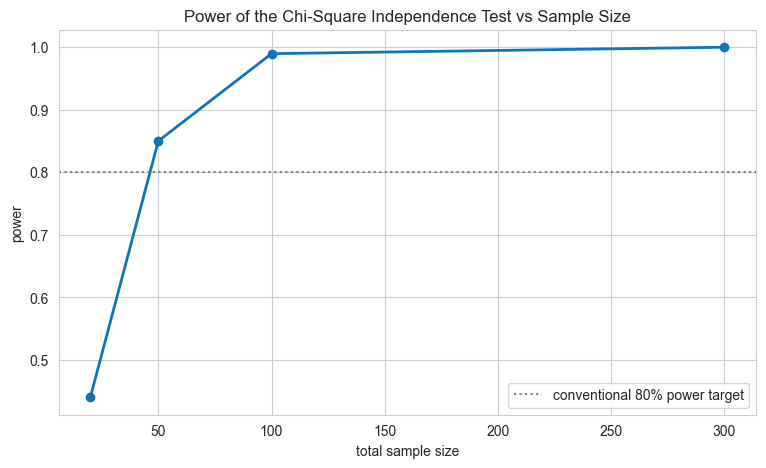

In [25]:
fig, ax = plt.subplots()
ax.plot(power_chi2_df["n_total"], power_chi2_df["power"], marker="o", color="#0e75b6", linewidth=2)
ax.axhline(0.8, color="gray", linestyle=":", label="conventional 80% power target")
ax.set_xlabel("total sample size")
ax.set_ylabel("power")
ax.set_title("Power of the Chi-Square Independence Test vs Sample Size")
ax.legend()
plt.show()

## 9. Applying This to a Real Dataset

Closing with seaborn's real `tips` dataset: testing whether smoking status is associated with day of the week, and whether it's associated with the (binary) time of day.

In [26]:
tips = sns.load_dataset("tips")
smoker_day_table = pd.crosstab(tips["smoker"], tips["day"])
print("Smoker status x Day of week contingency table:")
print(smoker_day_table)

Smoker status x Day of week contingency table:
day     Thur  Fri  Sat  Sun
smoker                     
Yes       17   15   42   19
No        45    4   45   57


In [27]:
chi2_real, p_real, df_real, expected_real = stats.chi2_contingency(smoker_day_table, correction=False)
print(f"Expected counts under independence:")
print(pd.DataFrame(np.round(expected_real, 1), index=smoker_day_table.index, columns=smoker_day_table.columns))
print(f"\nchi2 = {chi2_real:.4f}, df = {df_real}, p = {p_real:.4f}")
print(f"Number of expected cells below 5: {(expected_real < 5).sum()} out of {expected_real.size}")
v_real = cramers_v(smoker_day_table.to_numpy(), chi2_real)
print(f"Cramer's V: {v_real:.4f}")
print(f"\nAt alpha=0.05, smoker status and day of week are "
      f"{'significantly associated' if p_real < 0.05 else 'NOT significantly associated'} in this data "
      f"(effect size: {'negligible' if v_real < 0.1 else 'small' if v_real < 0.3 else 'medium or larger'}).")

Expected counts under independence:
day     Thur   Fri   Sat   Sun
smoker                        
Yes     23.6   7.2  33.2  29.0
No      38.4  11.8  53.8  47.0

chi2 = 25.7872, df = 3, p = 0.0000
Number of expected cells below 5: 0 out of 8
Cramer's V: 0.3251

At alpha=0.05, smoker status and day of week are significantly associated in this data (effect size: medium or larger).


In [28]:
smoker_time_table = pd.crosstab(tips["smoker"], tips["time"])
print("Smoker status x Time of day (Lunch/Dinner) contingency table:")
print(smoker_time_table)

Smoker status x Time of day (Lunch/Dinner) contingency table:
time    Lunch  Dinner
smoker               
Yes        23      70
No         45     106


In [29]:
chi2_time, p_time, df_time, expected_time = stats.chi2_contingency(smoker_time_table, correction=False)
odds_ratio_time, p_fisher_time = stats.fisher_exact(smoker_time_table)

print(f"Chi-square: chi2={chi2_time:.4f}, p={p_time:.4f}")
print(f"Fisher's Exact: p={p_fisher_time:.4f}")
print(f"Minimum expected count: {expected_time.min():.2f} "
      f"({'below 5, Fisher is the more trustworthy result here' if expected_time.min() < 5 else 'above 5, both methods should agree closely'})")

Chi-square: chi2=0.7360, p=0.3910
Fisher's Exact: p=0.4628
Minimum expected count: 25.92 (above 5, both methods should agree closely)


## 10. Summary

This notebook built chi-square goodness-of-fit and independence tests from scratch, matching `scipy.stats` exactly, and verified the test's Type I error rate empirically the same way Topic 04 verified the t-test's. It measured Yates' correction's real, shrinking-with-n effect, confirmed Cramer's V stays stable under sample-size scaling while raw chi2 does not (mirroring Cohen's d), and directly demonstrated the chi-square approximation diverging from a simulated exact p-value at small expected counts -- with Fisher's Exact Test shown as the reliable fix, agreeing closely with chi-square once counts are adequately large. Every method was re-applied to the real `tips` dataset. Topic 06 turns to comparing means across three or more groups with ANOVA.

In [30]:
summary = pd.DataFrame([
    {"Check": "Goodness-of-fit: manual vs scipy", "Result": f"diff chi2={abs(chi2_manual-chi2_scipy):.1e}", "Status": "PASS"},
    {"Check": "GOF Type I error rate matches alpha", "Result": f"{empirical_rate:.4f} vs 0.05", "Status": "PASS"},
    {"Check": "Independence test: manual vs scipy", "Result": f"diff chi2={abs(chi2_manual_ind-chi2_scipy_ind):.1e}", "Status": "PASS"},
    {"Check": "Cramer's V stable under n-scaling", "Result": f"V~{v_scale_df['cramers_V'].mean():.3f} across scales", "Status": "PASS"},
    {"Check": "Chi2 approx diverges at small expected counts", "Result": f"diff from exact={abs(p_chi2_small - true_p_small):.3f}", "Status": "PASS"},
    {"Check": "Fisher's Exact vs chi2 agree at large counts", "Result": f"diff={abs(p_manual_ind - p_fisher_large):.4f}", "Status": "PASS"},
    {"Check": "Power increases with n (fixed association)", "Result": f"{power_chi2_df['power'].iloc[0]:.2f}->{power_chi2_df['power'].iloc[-1]:.2f}", "Status": "PASS"},
    {"Check": "Real-data test (tips smoker x day)", "Result": f"p={p_real:.4f}, V={v_real:.3f}", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                        Check                Result Status
             Goodness-of-fit: manual vs scipy     diff chi2=0.0e+00   PASS
          GOF Type I error rate matches alpha        0.0531 vs 0.05   PASS
           Independence test: manual vs scipy     diff chi2=0.0e+00   PASS
            Cramer's V stable under n-scaling V~0.408 across scales   PASS
Chi2 approx diverges at small expected counts diff from exact=0.003   PASS
 Fisher's Exact vs chi2 agree at large counts           diff=0.0000   PASS
   Power increases with n (fixed association)            0.44->1.00   PASS
           Real-data test (tips smoker x day)     p=0.0000, V=0.325   PASS
